In [2]:
source("~/bin/lit_utils.R")
lib_text()
lib_plot()
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")

# 脚本目的
需要比较不同的方法鉴定出来的肽段和DB_search结果的一致性，使用Peptide recall来进行评估

其中:

peptide recall: correctly predicted spectra number/predicted labeled spectra number

coverage: predicted labeled spectra number/all labeled spectra number

使用C8柱富集，Trypsin酶消的replicate 1样本进行测试

该样本一共有117437（约12万）二级谱图数量

其中前体离子电荷数不为0的谱图数量有115463个

# 函数

In [3]:
# 函数定义
remove_start_zero <- function(psm){
    # 这个函数是为了对Fragpipe输出中的spectrum id做一些转换
    psm$Spectrum %>% stringr::str_split_fixed(.,"\\.",4) %>% .[,2] %>% gsub("^0+", "", .) -> scan_number
    psm$Spectrum %>% stringr::str_split_fixed(.,"\\.",4) %>% .[,1] -> prefix
    psm$Spectrum <- paste0(prefix,".",scan_number,".",scan_number,".",psm$Charge)
    psm$scan_number <- as.numeric(scan_number)
    return(psm)
}
compare_intersection <- function(peptide_1,peptide_2){
    # 比较同一张谱图两个方法得到的肽段是否一致
    gsub("I","L",peptide_1) -> peptide_1_I_L_equal
    gsub("I","L",peptide_2) -> peptide_2_I_L_equal
    sum(peptide_1==peptide_2) -> n_1
    sum(peptide_1_I_L_equal==peptide_2_I_L_equal) -> n_2
    return(data.frame(n_1,n_2))
}
compare_intersection_no_corre <- function(peptide_1,peptide_2){
    # 比较两个肽段集合的交集，交集是去重的
    gsub("I","L",peptide_1) -> peptide_1_I_L_equal
    gsub("I","L",peptide_2) -> peptide_2_I_L_equal
    length(intersect(peptide_1,peptide_2)) -> n_1
    length(intersect(peptide_1_I_L_equal,peptide_2_I_L_equal)) -> n_2
    return(data.frame(n_1,n_2))
}
remove_parentheses <- function(text) {
  # 使用正则表达式移除括号及其中的内容
  cleaned_text <- gsub("\\([^()]*\\)", "", text)
  return(cleaned_text)
}

# 具体比较

## DB_search


In [3]:
read_psm("/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/output/db_search_20250523/Trypsin/CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d/psm.tsv") -> c8_t_1_psm
remove_start_zero(c8_t_1_psm) -> c8_t_1_psm_1

Warning message in file(con, "r"):
“无法打开文件'/rd1/user/lit/project/sORFs/analysis/20250523_human_ms_run/output/db_search_20250523/Trypsin/CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d/psm.tsv': 没有那个文件或目录”


ERROR: Error in file(con, "r"): 无法打开链结


In [111]:
nrow(c8_t_1_psm_1)/total_spectrum_n

[1] 0.4765038

## PrimeNovo

In [68]:
read.table("./output/primenovo_20250623_processed_mgf/denovo.tsv",sep = '\t',header = T) -> primenovo_res
# 处理prediction列
primenovo_res <- primenovo_res %>%
  mutate(
    # 移除所有方括号及其内部内容（包括修饰符）
    # 移除所有连字符
    Peptide = gsub("\\[.*?\\]|-", "", prediction)
  )
# 处理label列
primenovo_res$label <- sub("_[^_]*$", "", primenovo_res$label)
primenovo_res %>% rename(Spectrum=label) -> primenovo_res

In [161]:
head(primenovo_res)

,Spectrum,prediction,charge,score,Peptide
,<chr>,<chr>,<int>,<dbl>,<chr>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.1.1.2,TFRVTVRPR,2,1.103320e-05,TFRVTVRPR
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.3.3.1,LTLRPK,1,2.280268e-03,LTLRPK
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.5.5.1,SEPPLLLLLR,1,8.411713e-06,SEPPLLLLLR
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.7.7.2,M[+15.995]YRC[+57.021]ARC[+57.021]RYR,2,2.495763e-08,MYRCARCRYR
5,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.9.9.2,[+43.006]-PDRRDLRTR,2,7.311872e-09,PDRRDLRTR
6,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.11.11.1,VELLPK,1,5.491716e-04,VELLPK


In [61]:
merge(primenovo_res,c8_t_1_psm_1,by="Spectrum") -> m_res
compare_intersection(m_res$Peptide.x,m_res$Peptide.y) -> overlap
overlap$n_2/nrow(m_res)

[1] 0.3027531

In [62]:
# 查看score分数的最大值和最小值
head(primenovo_res,1)
min(primenovo_res$score)
max(primenovo_res$score)

,Spectrum,prediction,charge,score,Peptide
,<chr>,<chr>,<int>,<dbl>,<chr>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.2.2.2,[+42.011]-RDRPPPVER,2,1.489237e-06,RDRPPPVER


[1] 3.089456e-29

[1] 0.9999968

In [70]:
read.table("./output/primenovo_20250623_processed_mgf/denovo.tsv",sep = '\t',header = T) -> primenovo_res
read.table("./output/primenovo_20250626_processed_mgf_20ppm/denovo.tsv",sep = '\t',header = T) -> primenovo_res_1

In [71]:
nrow(primenovo_res)
nrow(primenovo_res_1)

[1] 115463

[1] 115463

In [74]:
unique(primenovo_res$label) %>% length()
unique(primenovo_res_1$label) %>% length()

[1] 115463

[1] 115463

In [75]:
merge(primenovo_res,primenovo_res_1,by="label") %>% filter(prediction.x==prediction.y) %>% nrow()

[1] 115461

In [76]:
read.table("./output/primenovo_20250626_processed_mgf_20ppm/denovo.tsv",sep = '\t',header = T) -> primenovo_res
# 处理prediction列
primenovo_res <- primenovo_res %>%
  mutate(
    # 移除所有方括号及其内部内容（包括修饰符）
    # 移除所有连字符
    Peptide = gsub("\\[.*?\\]|-", "", prediction)
  )
# 处理label列
primenovo_res$label <- sub("_[^_]*$", "", primenovo_res$label)
primenovo_res %>% rename(Spectrum=label) -> primenovo_res
merge(primenovo_res,c8_t_1_psm_1,by="Spectrum") -> m_res
compare_intersection(m_res$Peptide.x,m_res$Peptide.y) -> overlap
overlap$n_2/nrow(m_res)

[1] 0.3027531

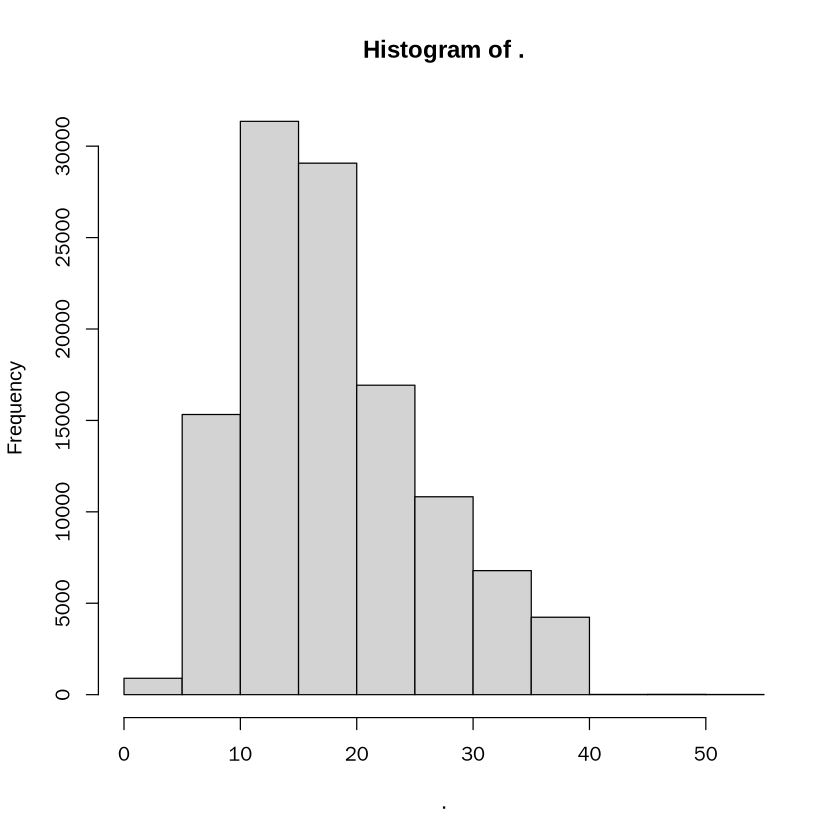

In [78]:
nchar(primenovo_res$Peptide) %>% hist()

## pUniFind

In [13]:
cus <- function(df){
    sub("_.*", "", df$V8) -> df$Peptide
    return(df)
}
read.csv("./output/pUniFind/tims_all_5_merged.csv",header = F) -> puni_res_1_all
cus(puni_res_1_all) -> puni_res_1_all
read.csv("./output/pUniFind/tims_all_5_filtered.csv",header = F) -> puni_res_1_filtered
cus(puni_res_1_filtered) -> puni_res_1_filtered
read.csv("./output/pUniFind/model_tims_tune/tims_all_5_merged.csv",header = F) -> puni_res_2_all
cus(puni_res_2_all) -> puni_res_2_all
read.csv("./output/pUniFind/model_tims_tune/tims_all_5_filtered.csv",header = F) -> puni_res_2_filtered
cus(puni_res_2_filtered) -> puni_res_2_filtered

## 具体比较

In [17]:
total_spectrum_n <- max(c8_t_1_psm_1$scan_number)
total_spectrum_n

[1] 117466

In [16]:
rename(puni_res_2_all,Spectrum=V1,score=V2) -> puni_res_2_all

In [15]:
calcu_para <- function(df,col,gt){
    df <- df[order(-df[,col]), ]
    thresholds <- seq(min(df[,col]), 
                  max(df[,col]), length.out = 100)
    # 初始化结果存储
    recall <- numeric(length(thresholds))
    coverage <- numeric(length(thresholds))
    accuracy <- numeric(length(thresholds))
    coverage_1 <- numeric(length(thresholds))

    for (i in seq_along(thresholds)) {
        # 筛选大于等于当前阈值的预测
        filtered <- df[df[,col] >= thresholds[i], ]

        # 计算 TP（True Positives）
        m_res <- merge(filtered, gt, by = "Spectrum")
        overlap_n <- nrow(m_res)
        compare_intersection(m_res$Peptide.x,m_res$Peptide.y) -> tmp
        true_positive_n <- tmp$n_2

        # recall 和 coverage
        recall[i] <- true_positive_n / overlap_n
        coverage[i] <- overlap_n / nrow(gt)
        accuracy[i] <- true_positive_n/ nrow(filtered)
        coverage_1[i] <- nrow(filtered)/ total_spectrum_n
    }
    rc_curve <- data.frame(Threshold = thresholds, Recall = recall, Coverage = coverage,
                          Accuracy=accuracy,Coverage_1=coverage_1)
    return(rc_curve)
}

In [18]:
calcu_para(primenovo_res,"score",c8_t_1_psm_1) -> rc_curve_1
calcu_para(puni_res_2_all,"score",c8_t_1_psm_1) -> rc_curve_2
rbind(mutate(rc_curve_1,Method="PrimeNovo"),
mutate(rc_curve_2,Method="pUniFind")) -> method_combined

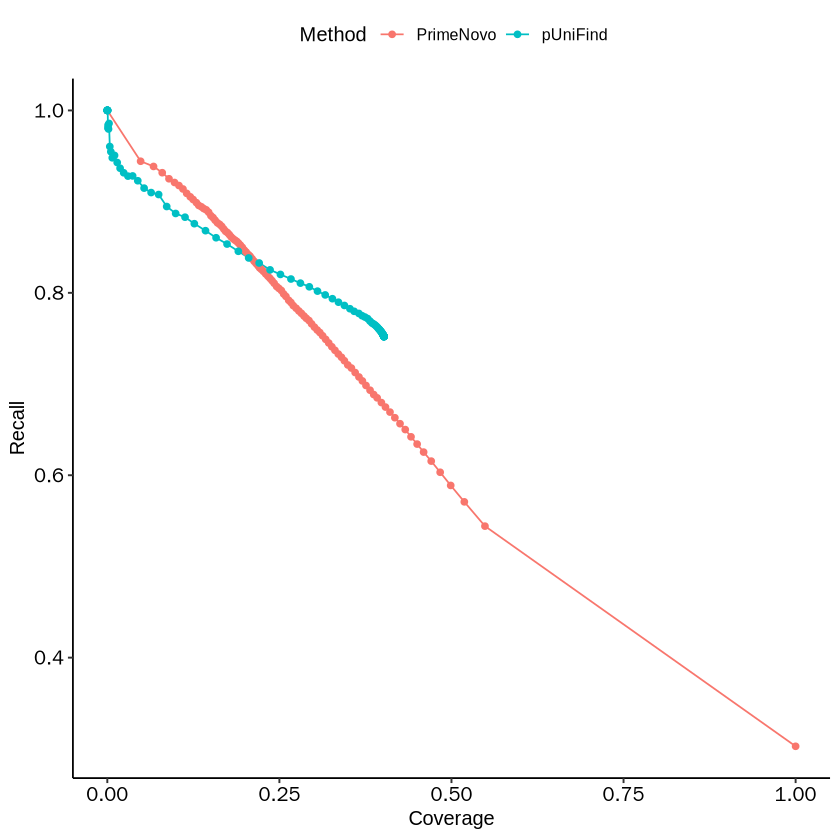

In [19]:
library(ggplot2)
ggplot(method_combined, aes(x = Coverage, y = Recall,color=Method)) +
  geom_line() +
  geom_point() +
theme_3()+
  labs( x = "Coverage", y = "Recall")  -> p
p

In [22]:
method_combined

Threshold,Recall,Coverage,Accuracy,Coverage_1,Method
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
3.089456e-29,0.3027531,1.0000000,0.1467656,0.9829483,PrimeNovo
1.010098e-02,0.5441550,0.5486574,0.3606717,0.3944375,PrimeNovo
2.020196e-02,0.5707840,0.5186786,0.3867301,0.3647779,PrimeNovo
3.030293e-02,0.5887914,0.4989013,0.4044374,0.3460916,PrimeNovo
4.040391e-02,0.6032215,0.4835903,0.4179594,0.3325728,PrimeNovo
5.050489e-02,0.6154518,0.4705840,0.4298290,0.3210716,PrimeNovo
6.060587e-02,0.6253402,0.4595430,0.4399858,0.3112220,PrimeNovo
7.070684e-02,0.6341192,0.4501099,0.4493320,0.3026833,PrimeNovo
8.080782e-02,0.6421023,0.4412306,0.4578077,0.2948853,PrimeNovo


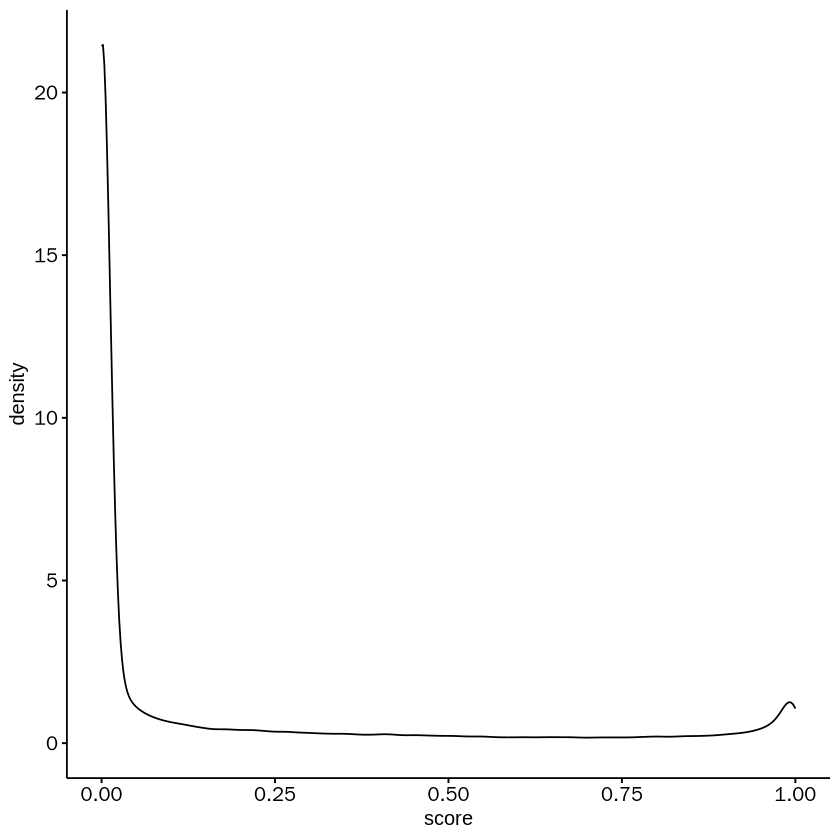

In [28]:
# 挺多的谱图分数特别低
ggdensity(data = primenovo_res,x = "score")

In [26]:
filter(rc_curve_1,Threshold>0.2)

Threshold,Recall,Coverage,Accuracy,Coverage_1
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.2020196,0.7077164,0.3655870,0.5278851,0.2335484
0.2121205,0.7125633,0.3600665,0.5325398,0.2295728
0.2222215,0.7175030,0.3545995,0.5376803,0.2254780
0.2323225,0.7209041,0.3493827,0.5416683,0.2215705
0.2424235,0.7255044,0.3444339,0.5465807,0.2178503
0.2525244,0.7293352,0.3401997,0.5513080,0.2144535
0.2626254,0.7328968,0.3355725,0.5553718,0.2110143
0.2727264,0.7369672,0.3307130,0.5599475,0.2074047
0.2828274,0.7408401,0.3262109,0.5641892,0.2041101


In [27]:
filter(primenovo_res,score>0.2) %>% nrow()

[1] 27519

In [29]:
nrow(c8_t_1_psm_1)/115463

[1] 0.48477

In [32]:
filter(rc_curve_1,Recall>=0.8) %>% head(1)
filter(rc_curve_2,Recall>=0.8)%>% head(1)

,Threshold,Recall,Coverage,Accuracy,Coverage_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.4747459,0.8025581,0.2528183,0.634115,0.1524697


,Threshold,Recall,Coverage,Accuracy,Coverage_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4.062217,0.8018371,0.3053615,0.6453664,0.1807842


In [36]:
filter(primenovo_res,score>=0.4747459) -> primenovo_res_filtered
filter(puni_res_2_all,score>=4.062217) -> puni_res_2_filtered
nrow(primenovo_res_filtered)
nrow(puni_res_2_filtered)

[1] 17910

[1] 21236

In [41]:
denovo_unique <- function(df){
    df[!df$Spectrum %in% c8_t_1_psm_1$Spectrum,] -> df_unique
    return(df_unique)
}
denovo_unique(primenovo_res_filtered) -> primenovo_res_filtered_unique
denovo_unique(puni_res_2_filtered) -> puni_res_2_filtered_unique

In [43]:
nrow(primenovo_res_filtered_unique)/115463
nrow(puni_res_2_filtered_unique)/115463

[1] 0.03255588

[1] 0.03589029

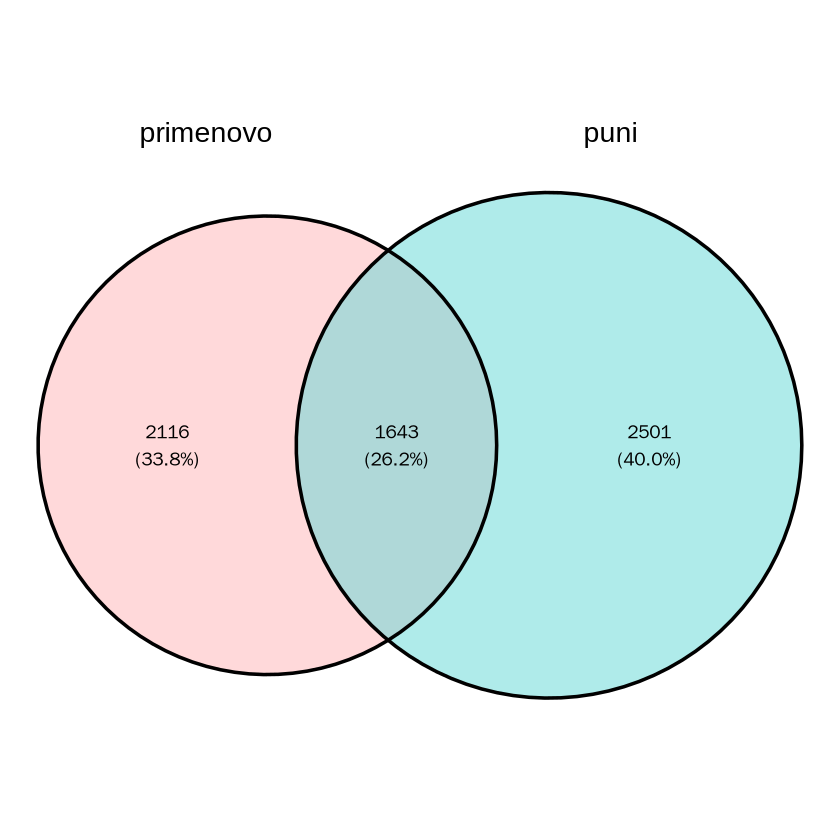

In [47]:
venn_plot_n(list = list(primenovo=primenovo_res_filtered_unique$Spectrum,
                       puni=puni_res_2_filtered_unique$Spectrum))

In [53]:
merge(primenovo_res_filtered_unique,puni_res_2_filtered_unique,by="Spectrum") %>% 
filter(Peptide.x==Peptide.y) %>% nrow()
592/1643

[1] 592

[1] 0.3603165

In [162]:
unique(c(primenovo_res_filtered_unique$Spectrum,
                       puni_res_2_filtered_unique$Spectrum)) %>% length() -> n
n
n/115463

[1] 6260

[1] 0.0542165

In [106]:
unique(c(primenovo_res_filtered_unique$Spectrum,
                       puni_res_2_filtered_unique$Spectrum)) -> denovo_iden_spectrum

In [107]:
head(denovo_iden_spectrum)

[1] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.96.96.3"  
[2] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.118.118.3"
[3] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.93.93.3"  
[4] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.181.181.4"
[5] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.282.282.3"
[6] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.286.286.3"

# 导入open search的结果

In [79]:
read_psm("/rd1/user/lit/project/sORFs/analysis/20250623_human_ms_rerun/output/db_search_c8_open_search/Trypsin/CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d/psm.tsv") -> c8_t_psm_open

In [83]:
colnames(c8_t_psm_open) %>% length()

[1] 55

In [82]:
head(c8_t_psm_open,5)

,Spectrum,Spectrum.File,Peptide,Modified.Peptide,Extended.Peptide,Prev.AA,Next.AA,Peptide.Length,Charge,Retention,⋯,Purity,Is.Unique,Protein,Protein.ID,Entry.Name,Gene,Protein.Description,Mapped.Genes,Mapped.Proteins,Sample
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.00090.00090.3,interact.pep.xml,KHEEEEAKAER,,KEVEQIIK.KHEEEEAKAER.EKKEKEQK,K,E,11,3,366.4339,⋯,0,false,sp|P25789|PSA4_HUMAN,P25789,PSA4_HUMAN,PSMA4,Proteasome subunit alpha type-4,,"ENST00000413382.6+chr15:78544920-78548944, ENST00000413382.6+chr15:78544929-78548944, ENST00000413382.6+chr15:78545656-78548944, ENST00000413382.6+chr15:78545659-78548944, ENST00000413382.6+chr15:78545665-78548944, ENST00000413382.6+chr15:78545677-78548944, ENST00000413382.6+chr15:78545734-78548944, ENST00000413382.6+chr15:78545746-78548944, ENST00000413382.6+chr15:78546580-78548944, ENST00000413382.6+chr15:78546586-78548944, ENST00000413382.6+chr15:78546589-78548944, ENST00000413382.6+chr15:78546616-78548944, ENST00000413382.6+chr15:78546622-78548944, ENST00000413382.6+chr15:78546625-78548944, ENST00000413382.6+chr15:78546646-78548944, ENST00000413382.6+chr15:78546661-78548944, ENST00000413382.6+chr15:78546667-78548944, ENST00000413382.6+chr15:78546697-78548944, ENST00000413382.6+chr15:78548794-78548944, ENST00000413382.6+chr15:78548821-78548944, ENST00000413382.6+chr15:78548830-78548944, ENST00000413382.6+chr15:78548854-78548944, ENST00000413382.6+chr15:78548863-78548944, ENST00000413382.6+chr15:78548866-78548944, ENST00000558281.5+chr15:78545763-78548944, ENST00000558341.5+chr15:78544257-78548944, ENST00000558341.5+chr15:78544266-78548944, sp|P25789-2|PSA4_HUMAN",21pcw_1_C8_T_T
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.00091.00091.3,interact.pep.xml,QSSEEKEAARR,,MGCR.QSSEEKEAARR.SRRIDRHI,R,S,11,3,369.5029,⋯,0,true,sp|P19086|GNAZ_HUMAN,P19086,GNAZ_HUMAN,GNAZ,Guanine nucleotide-binding protein G(z) subunit alpha,,,21pcw_1_C8_T_T
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.00092.00092.3,interact.pep.xml,EGSGSSGTGEQKEDQKEEK,,YKKMASER.EGSGSSGTGEQKEDQKEEK.,R,Q,19,3,370.0573,⋯,0,false,sp|P38646|GRP75_HUMAN,P38646,GRP75_HUMAN,HSPA9,"Stress-70 protein, mitochondrial",,"ENST00000524109.2-chr5:138556036-138556114, ENST00000524109.2-chr5:138556036-138556454, ENST00000524109.2-chr5:138556036-138556466, ENST00000524109.2-chr5:138556036-138556475, ENST00000524109.2-chr5:138556036-138556478, ENST00000524109.2-chr5:138556036-138556481, ENST00000524109.2-chr5:138556036-138556517, ENST00000524109.2-chr5:138556036-138556550, ENST00000524109.2-chr5:138556036-138556559, ENST00000524109.2-chr5:138556036-138556562, ENST00000524109.2-chr5:138556036-138556571, ENST00000524109.2-chr5:138556036-138556583, ENST00000524109.2-chr5:138556036-138556586, ENST00000524109.2-chr5:138556036-138556797, ENST00000524109.2-chr5:138556036-138556809, ENST00000524109.2-chr5:138556036-138556812, ENST00000524109.2-chr5:138556036-138556830, ENST00000524109.2-chr5:138556036-138556833, ENST00000524109.2-chr5:138556036-138556845, ENST00000524109.2-chr5:138556036-138556869, ENST00000677425.1-chr5:138556036-138557404, ENST00000677425.1-chr5:138556036-138557407, ENST00000677425.1-chr5:138556036-138557449, ENST00000677425.1-chr5:138556036-138557458, ENST00000677425.1-chr5:138556036-138557491, ENST00000677425.1-chr5:138556036-138557869, ENST00000678551.1-chr5:138556036-138557458, ENST00000678551.1-chr5:138556036-138557491, ENST00000678551.1-chr5:138556036-138557869, ENST00000678551.1-chr5:138556036-138557917, ENST00000678551.1-chr5:138556036-138557932, ENST00000678551.1-chr5:138556036-138557950, ENST00000678551.1-chr5:138556036-138557980, ENST00000678551.1-chr5:138556036-138557986, ENST00000678551.1-chr5:138556036-138558555",21pcw_1_C8_T_T
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.00093.00093.3,interact.pep.xml,KSSTPEEVKK,,VFNDMKVR.KSSTPEE

In [85]:
table(c8_t_psm_open$Observed.Modifications)


                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                  45248 
                                                                                                                                                                                                                              Mod1: (-)-dehydroepigallocatechin (Theoretical: 287.0556) 
                                                                                                                                                            

In [87]:
c8_t_psm_open %>% filter(Observed.Modifications!="") %>% nrow()

[1] 16311

In [89]:
16311/nrow(c8_t_psm_open)

[1] 0.2649653

In [93]:
read.table("/rd1/user/lit/project/sORFs/analysis/20250623_human_ms_rerun/output/db_search_c8_open_search/Trypsin/ptm-shepherd-output/global.modsummary.tsv",sep='\t',header=T) -> glob_psm

In [94]:
sum(glob_psm$CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d_percent_PSMs)

[1] 86.776

In [95]:
sum(glob_psm$CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2_3_1_7020_d_PSMs)

[1] 53436

In [96]:
53436-37092

[1] 16344

In [97]:
c8_t_psm_open %>% filter(Observed.Modifications!="") -> c8_t_psm_open_with_modi

In [98]:
head(c8_t_psm_open_with_modi,1)

,Spectrum,Spectrum.File,Peptide,Modified.Peptide,Extended.Peptide,Prev.AA,Next.AA,Peptide.Length,Charge,Retention,⋯,Purity,Is.Unique,Protein,Protein.ID,Entry.Name,Gene,Protein.Description,Mapped.Genes,Mapped.Proteins,Sample
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.00093.00093.3,interact.pep.xml,KSSTPEEVKK,,VFNDMKVR.KSSTPEEVKK.RKKAVIFC,R,R,10,3,370.802,⋯,0,false,sp|P23528|COF1_HUMAN,P23528,COF1_HUMAN,CFL1,Cofilin-1,,"ENST00000400899.2-chr1:10991539-10991740, ENST00000400899.2-chr1:10991539-10991746, ENST00000400899.2-chr1:10991539-10991758, ENST00000400899.2-chr1:10991539-10991761, ENST00000400899.2-chr1:10991539-10991764, ENST00000400899.2-chr1:10991539-10991779, ENST00000400899.2-chr1:10991539-10991785, ENST00000400899.2-chr1:10991539-10991797, ENST00000530945.1-chr11:65855930-65856182, ENST00000530945.1-chr11:65855930-65856188, ENST00000530945.1-chr11:65855930-65856191, ENST00000530945.1-chr11:65855930-65856194, ENST00000530945.1-chr11:65855930-65856206, ENST00000530945.1-chr11:65855930-65856209, ENST00000530945.1-chr11:65855930-65856212, ENST00000530945.1-chr11:65855930-65856233, ENST00000530945.1-chr11:65855930-65858099, ENST00000534769.5-chr11:65855335-65856182, ENST00000534769.5-chr11:65855335-65856188, ENST00000534769.5-chr11:65855335-65856191, ENST00000534769.5-chr11:65855335-65856194",21pcw_1_C8_T_T


In [99]:
remove_start_zero(c8_t_psm_open_with_modi) -> c8_t_psm_open_with_modi_1

In [103]:
sum(!c8_t_psm_open_with_modi_1$Spectrum %in% c8_t_1_psm_1$Spectrum)

[1] 10796

In [105]:
spectrum_unique <- function(df){
    df[!df$Spectrum %in% c8_t_1_psm_1$Spectrum,] -> df_unique
    return(df_unique)
}
spectrum_unique(c8_t_psm_open_with_modi_1) -> c8_t_psm_open_with_modi_1_unique

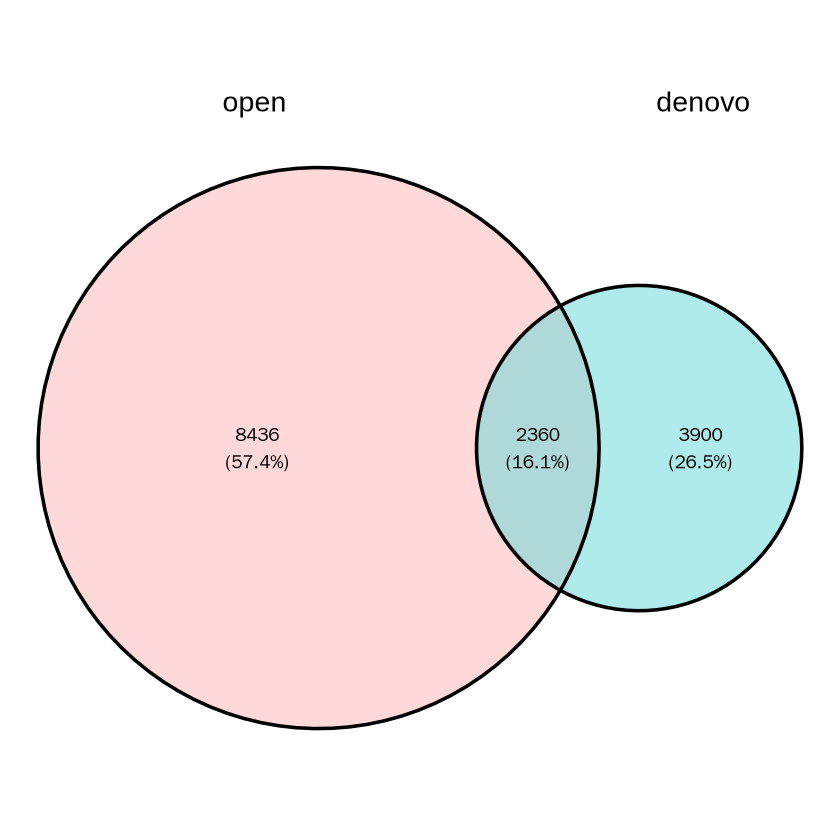

In [108]:
venn_plot_n(list = list(open=c8_t_psm_open_with_modi_1_unique$Spectrum,
                       denovo=denovo_iden_spectrum))

In [110]:
(8436+2360+3900)/total_spectrum_n

[1] 0.1251085

In [112]:
(nrow(c8_t_1_psm_1)+(8436+2360+3900))/total_spectrum_n

[1] 0.6016124

# 导入pfind以及open-pfind的结果

In [118]:
read.table("./output/pfind-default/pFind-Filtered.spectra",sep = '\t',header = T) -> pFind_res
# head(pFind_res,1)

File_Name                                                                               
1 CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.109264.109264.3_SCANS109264
  Scan_No Exp.MH.  Charge Q.value Sequence                         Calc.MH.
1 109264  3602.702 3      0       FQSSAVMALQEACEAYLVGLFEDTNLCAIHAK 3602.696
  Mass_Shift.Exp..Calc.. Raw_Score Final_Score
1 0.005451               40.82173  1.44721e-11
  Modification                                                Specificity
1 7,Oxidation[M];13,Carbamidomethyl[C];27,Carbamidomethyl[C]; 3          
  Proteins                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [123]:
read.table("./output/pfind-open/pFind-Filtered.contain_other_modi.spectra",sep = '\t',header = T) -> open_pFind_res
# head(open_pFind_res,1)

,File_Name,Scan_No,Exp.MH.,Charge,Q.value,Sequence,Calc.MH.,Mass_Shift.Exp..Calc..,Raw_Score,Final_Score,Modification,Specificity,Proteins,Positions,Label,Target.Decoy,Miss.Clv.Sites,Avg.Frag.Mass.Shift,Others
,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.94152.94152.3_SCANS94152,94152,3119.629,3,0,NIILEEGKEILVGDVGQTVDDPYATFVK,3119.615,0.014951,33.14456,1.81098e-09,"28,Carbamidomethyl[K](Gly[K]);",3,sp|P23528|COF1_HUMAN/ENST00000530945.1-chr11:65855930-65856113/ENST00000530945.1-chr11:65855930-65856116/ENST00000530945.1-chr11:65855930-65856128/ENST00000530945.1-chr11:65855930-65856140/ENST00000530945.1-chr11:65855930-65856146/ENST00000530945.1-chr11:65855930-65856149/ENST00000530945.1-chr11:65855930-65856155/ENST00000530945.1-chr11:65855930-65856158/ENST00000530945.1-chr11:65855930-65856161/ENST00000530945.1-chr11:65855930-65856173/ENST00000530945.1-chr11:65855930-65856182/ENST00000530945.1-chr11:65855930-65856188/ENST00000530945.1-chr11:65855930-65856191/ENST00000530945.1-chr11:65855930-65856194/ENST00000530945.1-chr11:65855930-65856206/ENST00000530945.1-chr11:65855930-65856209/ENST00000530945.1-chr11:65855930-65856212/ENST00000530945.1-chr11:65855930-65856233/ENST00000530945.1-chr11:65855930-65858099/ENST00000534769.5-chr11:65855335-65856113/ENST00000534769.5-chr11:65855335-65856116/ENST00000534769.5-chr11:65855335-65856128/ENST00000534769.5-chr11:65855335-65856140/ENST00000534769.5-chr11:65855335-65856146/ENST00000534769.5-chr11:65855335-65856149/ENST00000534769.5-chr11:65855335-65856155/ENST00000534769.5-chr11:65855335-65856158/ENST00000534769.5-chr11:65855335-65856161/ENST00000534769.5-chr11:65855335-65856173/ENST00000534769.5-chr11:65855335-65856182/ENST00000534769.5-chr11:65855335-65856188/ENST00000534769.5-chr11:65855335-65856191/ENST00000534769.5-chr11:65855335-65856194/,"45,K,M/1,K,M/2,K,M/6,K,M/10,K,M/12,K,M/13,K,M/15,K,M/16,K,M/17,K,M/21,K,M/24,K,M/26,K,M/27,K,M/28,K,M/32,K,M/33,K,M/34,K,M/41,K,M/45,K,M/1,K,M/2,K,M/6,K,M/10,K,M/12,K,M/13,K,M/15,K,M/16,K,M/17,K,M/21,K,M/24,K,M/26,K,M/27,K,M/28,K,M/",1|0|,target,1,0.093755,100


In [124]:
head(open_pFind_res$Modification,10)

[1] "28,Carbamidomethyl[K](Gly[K]);"                                           
 [2] "17,Deamidated[N];"                                                        
 [3] "0,Carbamidomethyl[AnyN-term];6,Carbamidomethyl[C];"                       
 [4] "0,Carbamidomethyl[AnyN-term];6,Carbamidomethyl[C];"                       
 [5] "0,Carbamidomethyl[AnyN-term];"                                            
 [6] "6,Carbamidomethyl[M];"                                                    
 [7] "0,Carbamidomethyl[AnyN-term];"                                            
 [8] "0,Carbamidomethyl[AnyN-term];13,Carbamidomethyl[C];27,Carbamidomethyl[C];"
 [9] "0,Carbamidomethyl[AnyN-term];6,Carbamidomethyl[C];31,Carbamidomethyl[M];" 
[10] "27,GG[C](Dicarbamidomethyl[C]);"

In [125]:
colnames(open_pFind_res)

[1] "File_Name"              "Scan_No"                "Exp.MH."               
 [4] "Charge"                 "Q.value"                "Sequence"              
 [7] "Calc.MH."               "Mass_Shift.Exp..Calc.." "Raw_Score"             
[10] "Final_Score"            "Modification"           "Specificity"           
[13] "Proteins"               "Positions"              "Label"                 
[16] "Target.Decoy"           "Miss.Clv.Sites"         "Avg.Frag.Mass.Shift"   
[19] "Others"

In [129]:
head(pFind_res$File_Name)
head(pFind_res$File_Name) %>% 

[1] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.109264.109264.3_SCANS109264"
[2] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.111447.111447.3_SCANS111447"
[3] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.94384.94384.3_SCANS94384"   
[4] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.76970.76970.3_SCANS76970"   
[5] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.112710.112710.3_SCANS112710"
[6] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.72519.72519.4_SCANS72519"

[1] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.109264.109264.3"
[2] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.111447.111447.3"
[3] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.94384.94384.3"  
[4] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.76970.76970.3"  
[5] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.112710.112710.3"
[6] "CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.72519.72519.4"

In [131]:
gen_spectrum <- function(df){
   sub("_[^_]*$", "", df$File_Name) -> df$Spectrum
    return(df)
}
gen_spectrum(pFind_res)->pFind_res
gen_spectrum(open_pFind_res)->open_pFind_res

In [134]:
sum(pFind_res$Spectrum %in% c8_t_1_psm_1$Spectrum)
nrow(pFind_res)

[1] 42167

[1] 45486

# 合并看看鉴定率的增加

In [ ]:
c8_t_1_psm_1
pFind_res
c8_t_psm_open_with_modi_1
open_pFind_res
puni_res_2_filtered
primenovo_res_filtered

In [143]:
# head(c8_t_1_psm_1$Peptide)
head(pFind_res$Sequence)
pFind_res %>% rename(Peptide=Sequence)->pFind_res
open_pFind_res %>% rename(Peptide=Sequence)->open_pFind_res

[1] "FQSSAVMALQEACEAYLVGLFEDTNLCAIHAK"  "FQSAAIGALQEASEAYLVGLFEDTNLCAIHAK" 
[3] "NIILEEGKEILVGDVGQTVDDPYATFVK"      "CLQGFQLTHSLGGGTGSGMGTLLISK"       
[5] "FQSSAVMALQEASEAYLVGLFEDTNLCAIHAK"  "KECENCDCLQGFQLTHSLGGGTGSGMGTLLISK"

In [146]:
puni_res_2_filtered$Peptide %>% head()
primenovo_res_filtered$Peptide %>% head()

[1] "LCQFHR"           "FTMEIAK"          "AVTEQGHELSNEER"   "TVLPGMPTVIPPGTLR"
[5] "LGEWVGLCK"        "LDHAIVEVVTCLLR"

[1] "KSSTPEEVKRK"   "YKAEDEQRK"     "SRPETGRPRPK"   "KTKEDEKDDKPLR"
[5] "KSSTPEEVKRK"   "LAHYNKR"

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


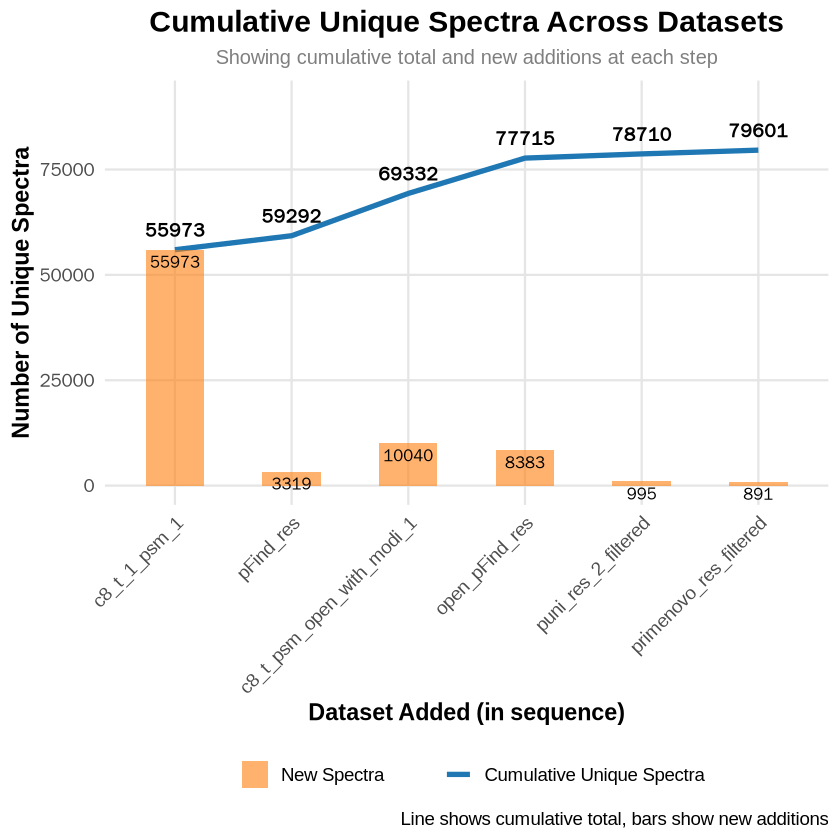

In [136]:
library(dplyr)
library(ggplot2)

# 假设您已经将6个数据框加载到R环境中
# 数据框名称：c8_t_1_psm_1, pFind_res, c8_t_psm_open_with_modi_1, 
#             open_pFind_res, puni_res_2_filtered, primenovo_res_filtered

# 1. 创建数据框列表（按顺序）
df_list <- list(
  c8_t_1_psm_1,
  pFind_res,
  c8_t_psm_open_with_modi_1,
  open_pFind_res,
  puni_res_2_filtered,
  primenovo_res_filtered
)

# 2. 命名列表元素
names(df_list) <- c(
  "msFragger",
  "pFind",
  "open-msFragger",
  "open_pFind",
  "pUniFind",
  "primeNovo"
)

# 3. 创建累积数据框
cumulative_data <- tibble(
  Dataset = character(),
  Cumulative_Unique_Spectra = numeric(),
  Step = integer()
)

# 初始化累积频谱集合
all_spectra <- character()

# 4. 逐步处理每个数据框
for (i in seq_along(df_list)) {
  # 获取当前数据框
  current_df <- df_list[[i]]
  
  # 确保有 Spectrum 列
  if (!"Spectrum" %in% names(current_df)) {
    stop(paste("Data frame", names(df_list)[i], "does not have 'Spectrum' column"))
  }
  
  # 获取当前数据框的唯一 Spectrum
  current_spectra <- unique(current_df$Spectrum)
  
  # 添加到累积集合
  all_spectra <- union(all_spectra, current_spectra)
  
  # 添加到结果数据框
  cumulative_data <- cumulative_data %>% 
    add_row(
      Dataset = names(df_list)[i],
      Cumulative_Unique_Spectra = length(all_spectra),
      Step = i
    )
}

# 5. 计算每步新增数量
cumulative_data <- cumulative_data %>%
  mutate(
    New_Spectra = Cumulative_Unique_Spectra - lag(Cumulative_Unique_Spectra, default = 0)
  )

# 6. 可视化
ggplot(cumulative_data, aes(x = factor(Step, labels = Dataset), group = 1)) +
  # 累积数量线图
  geom_line(aes(y = Cumulative_Unique_Spectra, color = "Cumulative Unique Spectra"), 
            size = 1.5, linetype = "solid") +
  # 新增数量柱状图
  geom_col(aes(y = New_Spectra, fill = "New Spectra"), 
           alpha = 0.6, width = 0.5) +
  # 数据标签
  geom_text(aes(y = Cumulative_Unique_Spectra, 
                label = Cumulative_Unique_Spectra),
            vjust = -1, size = 4, color = "black", fontface = "bold") +
  geom_text(aes(y = New_Spectra, 
                label = ifelse(New_Spectra > 0, New_Spectra, "")),
            vjust = 1.5, size = 3.5, color = "black") +
  # 标题和标签
  labs(title = "Cumulative Unique Spectra Across Datasets",
       subtitle = "Showing cumulative total and new additions at each step",
       x = "Dataset Added (in sequence)",
       y = "Number of Unique Spectra",
       caption = "Line shows cumulative total, bars show new additions") +
  # 颜色和填充设置
  scale_color_manual(name = "", values = c("Cumulative Unique Spectra" = "#1f77b4")) +
  scale_fill_manual(name = "", values = c("New Spectra" = "#ff7f0e")) +
  # 主题设置
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    plot.subtitle = element_text(hjust = 0.5, size = 12, color = "gray50"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    legend.position = "bottom",
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = "white", color = NA)
  ) +
  # 扩展Y轴范围以容纳标签
  expand_limits(y = max(cumulative_data$Cumulative_Unique_Spectra) * 1.15)

# 7. 保存图表
ggsave("cumulative_spectra_plot.png", width = 12, height = 8, dpi = 300)

In [160]:
55973/total_spectrum_n
79601/total_spectrum_n

[1] 0.4765038

[1] 0.6776514

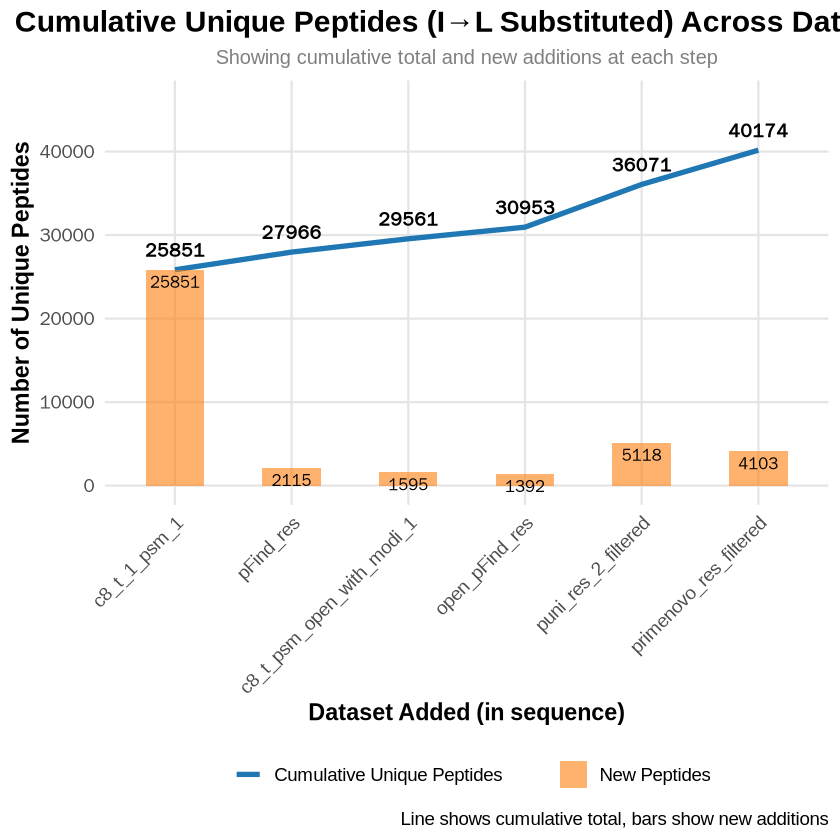

In [159]:
# library(tidyverse)
library(ggplot2)
library(scales)

# 1. 创建数据框列表（按顺序）
df_list <- list(
  c8_t_1_psm_1,
  pFind_res,
  c8_t_psm_open_with_modi_1,
  open_pFind_res,
  puni_res_2_filtered,
  primenovo_res_filtered
)

# 2. 命名列表元素
names(df_list) <- c(
  "msFragger",
  "pFind",
  "open-msFragger",
  "open_pFind",
  "pUniFind",
  "primeNovo"
)

# 3. 为每个数据框添加 Peptide_I_L_equal 列
for (i in seq_along(df_list)) {
    df_list[[i]]$Peptide_I_L_equal <- gsub("I", "L", df_list[[i]]$Peptide)
}

# 3. 创建累积数据框
cumulative_data <- tibble(
  Dataset = character(),
  Cumulative_Unique_Peptides = numeric(),  # 修改为 Peptides
  Step = integer()
)

# 初始化累积肽段集合
all_peptides <- character()  # 修改为 peptides

# 4. 逐步处理每个数据框
for (i in seq_along(df_list)) {
  # 获取当前数据框
  current_df <- df_list[[i]]
  
  # 获取当前数据框的唯一肽段序列 (Peptide_I_L_equal)
  current_peptides <- unique(current_df$Peptide_I_L_equal)  # 修改为 peptides
  
  # 添加到累积集合
  all_peptides <- union(all_peptides, current_peptides)  # 修改为 peptides
  
  # 添加到结果数据框
  cumulative_data <- cumulative_data %>% 
    add_row(
      Dataset = names(df_list)[i],
      Cumulative_Unique_Peptides = length(all_peptides),  # 修改为 Peptides
      Step = i
    )
}

# 5. 计算每步新增数量
cumulative_data <- cumulative_data %>%
  mutate(
    New_Peptides = Cumulative_Unique_Peptides - lag(Cumulative_Unique_Peptides, default = 0)  # 修改为 Peptides
  )

# 6. 可视化
ggplot(cumulative_data, aes(x = factor(Step, labels = Dataset), group = 1)) +
  # 累积数量线图
  geom_line(aes(y = Cumulative_Unique_Peptides, color = "Cumulative Unique Peptides"),  # 修改为 Peptides
            size = 1.5, linetype = "solid") +
  # 新增数量柱状图
  geom_col(aes(y = New_Peptides, fill = "New Peptides"),  # 修改为 Peptides
           alpha = 0.6, width = 0.5) +
  # 数据标签
  geom_text(aes(y = Cumulative_Unique_Peptides,  # 修改为 Peptides
                label = Cumulative_Unique_Peptides),  # 修改为 Peptides
            vjust = -1, size = 4, color = "black", fontface = "bold") +
  geom_text(aes(y = New_Peptides,  # 修改为 Peptides
                label = ifelse(New_Peptides > 0, New_Peptides, "")),  # 修改为 Peptides
            vjust = 1.5, size = 3.5, color = "black") +
  # 标题和标签
  labs(title = "Cumulative Unique Peptides (I→L Substituted) Across Datasets",  # 修改标题
       subtitle = "Showing cumulative total and new additions at each step",
       x = "Dataset Added (in sequence)",
       y = "Number of Unique Peptides",  # 修改Y轴标签
       caption = "Line shows cumulative total, bars show new additions") +
  # 颜色和填充设置
  scale_color_manual(name = "", values = c("Cumulative Unique Peptides" = "#1f77b4")) +  # 修改图例
  scale_fill_manual(name = "", values = c("New Peptides" = "#ff7f0e")) +  # 修改图例
  # 主题设置
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    plot.subtitle = element_text(hjust = 0.5, size = 12, color = "gray50"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    legend.position = "bottom",
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = "white", color = NA)
  ) +
  # 扩展Y轴范围以容纳标签
  expand_limits(y = max(cumulative_data$Cumulative_Unique_Peptides) * 1.15)  # 修改为 Peptides

# 7. 保存图表
ggsave("cumulative_peptides_plot.png", width = 12, height = 8, dpi = 300)

# 按照一定的层级merge

In [182]:
cols <- c("Spectrum",'Peptide_I_L_equal',"Source")
df_list <- list(
  c8_t_1_psm_1,
  pFind_res,
  c8_t_psm_open_with_modi_1,
  open_pFind_res,
  puni_res_2_filtered,
  primenovo_res_filtered
)
names(df_list) <- c(
  "msFragger",
  "pFind",
  "open-msFragger",
  "open_pFind",
  "pUniFind",
  "primeNovo"
)
for (i in seq_along(df_list)) {
    df_list[[i]]$Peptide_I_L_equal <- gsub("I", "L", df_list[[i]]$Peptide)
}

In [184]:
# 2. 按顺序合并数据框并去重
combined_df <- bind_rows(df_list, .id = "Source") %>%
  # 按添加顺序排序（保持原始顺序）
  mutate(Source = factor(Source, levels = names(df_list))) %>%
  arrange(Source) %>%
  
  # 根据 Spectrum 去重（保留每个 Spectrum 的第一个出现）
  distinct(Spectrum, .keep_all = TRUE)  %>% 
  
  # 选择所需列
  select(all_of(cols))

In [185]:
head(combined_df)

,Spectrum,Peptide_I_L_equal,Source
,<chr>,<chr>,<fct>
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.90.90.3,KHEEEEAKAER,msFragger
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.91.91.3,QSSEEKEAARR,msFragger
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.92.92.3,EGSGSSGTGEQKEDQKEEK,msFragger
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.101.101.3,YKAEDEKQR,msFragger
5,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.102.102.3,YKAEDEKQR,msFragger
6,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.103.103.3,HGSSSGSSSSYGQHGSGSR,msFragger


In [186]:
n_distinct(combined_df$Peptide_I_L_equal)

[1] 31151

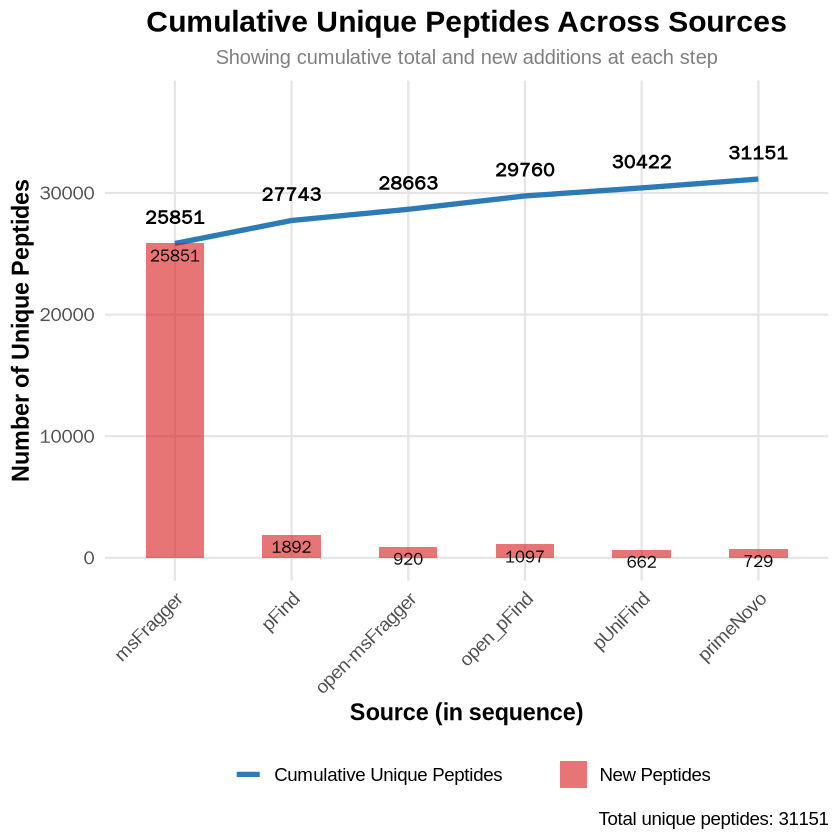

In [193]:
library(dplyr)
library(ggplot2)
library(scales)

# 确保 Source 按原始顺序排列（重要！）
combined_df <- combined_df %>%
  mutate(Source = factor(Source, levels = unique(Source)))

# 1. 准备累积数据（正确方法）
cumulative_data <- tibble(
  Source = character(),
  Cumulative_Unique_Peptides = numeric(),
  New_Peptides = numeric(),
  Step = integer()
)

# 初始化累积肽段集合
all_peptides <- character()

# 获取唯一的 Source 顺序
source_levels <- levels(combined_df$Source)

# 2. 逐步处理每个 Source
for (i in seq_along(source_levels)) {
  current_source <- source_levels[i]
  
  # 获取当前 Source 的所有肽段
  current_peptides <- combined_df %>%
    filter(Source == current_source) %>%
    pull(Peptide_I_L_equal) %>%
    unique()
  
  # 计算新增肽段（不在之前任何 Source 中的肽段）
  new_peptides <- setdiff(current_peptides, all_peptides)
  new_count <- length(new_peptides)
  
  # 更新累积集合
  all_peptides <- union(all_peptides, current_peptides)
  
  # 添加到结果数据框
  cumulative_data <- cumulative_data %>% 
    add_row(
      Source = current_source,
      Cumulative_Unique_Peptides = length(all_peptides),
      New_Peptides = new_count,
      Step = i
    )
}

cumulative_data$Source <- factor(cumulative_data$Source,levels = levels(combined_df$Source))
# 4. 创建可视化
p <- ggplot(cumulative_data, aes(x = Source, group = 1)) +
  # 累积数量线图
  geom_line(aes(y = Cumulative_Unique_Peptides, color = "Cumulative Unique Peptides"), 
            size = 1.5, linetype = "solid") +
  
  # 新增数量柱状图
  geom_col(aes(y = New_Peptides, fill = "New Peptides"), 
           alpha = 0.6, width = 0.5) +
  
  # 数据标签 - 累积数量
  geom_text(aes(y = Cumulative_Unique_Peptides, 
                label = Cumulative_Unique_Peptides),
            vjust = -1.5, size = 4, color = "black", fontface = "bold") +
  
  # 数据标签 - 新增数量
  geom_text(aes(y = New_Peptides, 
                label = ifelse(New_Peptides > 0, New_Peptides, "")),
            vjust = 1.5, size = 3.5, color = "black") +
  # 标题和标签
  labs(title = "Cumulative Unique Peptides Across Sources",
       subtitle = "Showing cumulative total and new additions at each step",
       x = "Source (in sequence)",
       y = "Number of Unique Peptides",
       caption = paste("Total unique peptides:", max(cumulative_data$Cumulative_Unique_Peptides)),
       color = "", fill = "") +
  
  # 颜色和填充设置
  scale_color_manual(values = c("Cumulative Unique Peptides" = "#2c7bb6")) +
  scale_fill_manual(values = c("New Peptides" = "#d7191c")) +
  
  # 主题设置
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    plot.subtitle = element_text(hjust = 0.5, size = 12, color = "gray50"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    legend.position = "bottom",
    panel.grid.major = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = "white", color = NA)
  ) +
  
  # 扩展Y轴范围以容纳标签
  expand_limits(y = max(cumulative_data$Cumulative_Unique_Peptides) * 1.2)

# 5. 保存和显示图表
ggsave("corrected_cumulative_peptides_by_source.png", p, width = 12, height = 8, dpi = 300)
print(p)

# 6. 保存数据
write.csv(cumulative_data, "corrected_cumulative_peptides_by_source.csv", row.names = FALSE)

In [188]:
cumulative_data

Source,Current_Unique_Peptides,Cumulative_Unique_Peptides,New_Peptides,Cumulative_Percent
<fct>,<int>,<int>,<int>,<dbl>
msFragger,25851,25851,25851,68.64130
pFind,2213,28064,2213,74.51741
open-msFragger,3902,31966,3902,84.87826
open_pFind,4005,35971,4005,95.51260
pUniFind,844,36815,844,97.75364
primeNovo,846,37661,846,100.00000
